# Notebook 03 — Detector evaluation

End-to-end pipeline test:
1. Simulate noisy EIS spectra for degraded and healthy scenarios.
2. Fit Randles circuit to each spectrum to extract Rct.
3. Run CUSUM change-point detector on the Rct time series.
4. Report: detection lead time, true-positive rate, false-positive rate.

**Falsifiable claim this notebook tests:**
> On this synthetic dataset (N=60 oxidation, N=60 evaporation, N=30 healthy;
> SNR 40 dB), the CUSUM detector flags degradation with median lead time ≥ 50 h
> before the Rct failure threshold, at a false-positive rate ≤ 10%.

**What this does not prove:** real-world performance; robustness to temperature
drift, bath chemistry variation, or cable-induced parasitic inductance.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # pip install tqdm if not present

from randles_model import moe_frequencies, moe_anode_baseline
from degradation_sim import (
    oxidation_trajectory,
    evaporation_trajectory,
    healthy_trajectory,
)
from detector import (
    fit_scenario,
    extract_rct,
    cusum_detector,
    evaluate,
    DetectorMetrics,
)

In [2]:
rng = np.random.default_rng(42)
freqs = moe_frequencies(n_per_decade=10)
baseline = moe_anode_baseline()

# Build scenario pool
scenarios = []

# Vary degradation rate via total_hours (faster = more severe scenario)
for total_h in np.linspace(300, 600, 30):
    scenarios.append(oxidation_trajectory(baseline, n_steps=100, total_hours=total_h))
    scenarios.append(evaporation_trajectory(baseline, n_steps=100, total_hours=total_h * 0.6))

for _ in range(30):
    scenarios.append(healthy_trajectory(baseline, n_steps=100, total_hours=500, rng=rng))

n_deg = sum(1 for s in scenarios if s.failure_hour is not None)
n_hlth = len(scenarios) - n_deg
print(f"Scenarios: {n_deg} degraded, {n_hlth} healthy, {len(scenarios)} total")

Scenarios: 60 degraded, 30 healthy, 90 total


In [3]:
# Evaluate at a single (threshold, drift) setting
metrics = evaluate(
    scenarios,
    frequencies=freqs,
    snr_db=40.0,
    cusum_threshold=10.0,
    cusum_drift=0.05,
    rng=rng,
)

print(f"True-positive rate  : {metrics.true_positive_rate:.1%}")
print(f"False-positive rate : {metrics.false_positive_rate:.1%}")
print(f"Median lead time    : {metrics.median_lead_hours:.1f} h")
print(f"Min lead time       : {metrics.min_lead_hours:.1f} h")

True-positive rate  : 100.0%
False-positive rate : 0.0%
Median lead time    : 211.5 h
Min lead time       : 96.4 h


Pre-fitting all scenarios (runs once)...


Done. 90 scenarios cached.


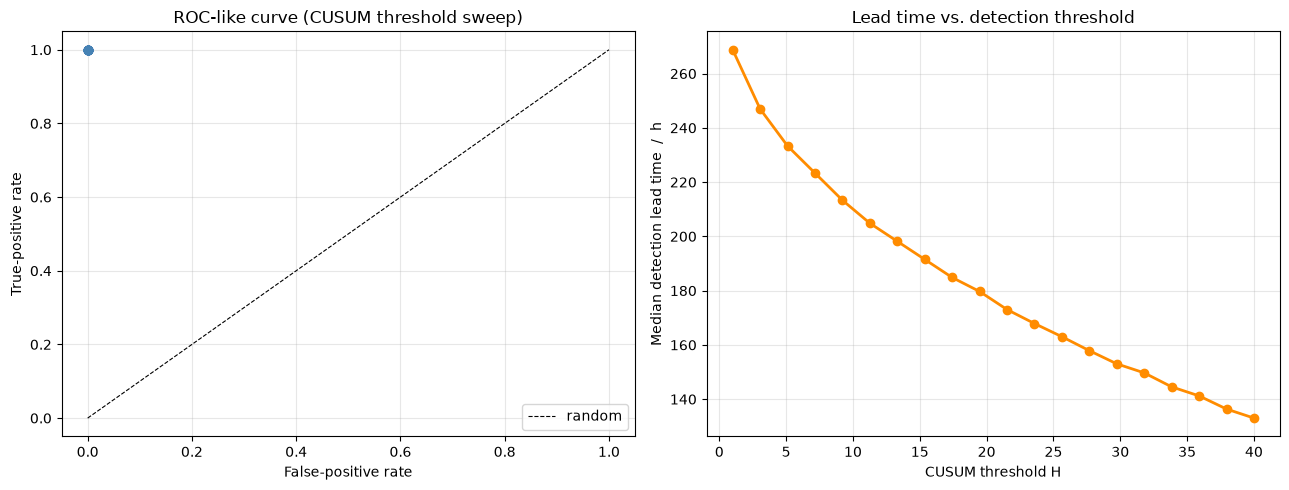

In [4]:
# ── Threshold sweep — ROC-like curve ─────────────────────────────────────────
# Pre-fit all scenarios ONCE, cache the Rct series.
# Then sweep thresholds over cached results (no re-fitting per threshold).

import sys
sys.path.insert(0, '..')
from detector import fit_scenario, extract_rct, cusum_detector

print('Pre-fitting all scenarios (runs once)...')
cached = []
for scenario in scenarios:
    fitted = fit_scenario(scenario, frequencies=freqs, snr_db=40.0, rng=np.random.default_rng(42))
    rct = extract_rct(fitted)
    cached.append((scenario, rct))
print(f'Done. {len(cached)} scenarios cached.')

thresholds = np.linspace(1.0, 40.0, 20)
tprs, fprs, medians = [], [], []

for thr in thresholds:
    leads = []
    tp = 0
    fp = 0
    n_deg = sum(1 for s, _ in cached if s.failure_hour is not None)
    n_hlth = len(cached) - n_deg
    for scenario, rct in cached:
        baseline_rct = scenario.params[0].Rct
        result = cusum_detector(rct, scenario.hours, baseline_rct=baseline_rct,
                                threshold=thr, drift=0.05, failure_hour=scenario.failure_hour)
        if scenario.failure_hour is not None:
            if result.alert_index is not None:
                tp += 1
                leads.append(result.lead_hours or 0.0)
        else:
            if result.alert_index is not None:
                fp += 1
    tprs.append(tp / n_deg if n_deg > 0 else float('nan'))
    fprs.append(fp / n_hlth if n_hlth > 0 else float('nan'))
    medians.append(float(np.median(leads)) if leads else 0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fprs, tprs, 'o-', lw=2, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, label='random')
axes[0].set_xlabel('False-positive rate')
axes[0].set_ylabel('True-positive rate')
axes[0].set_title('ROC-like curve (CUSUM threshold sweep)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, medians, 'o-', lw=2, color='darkorange')
axes[1].set_xlabel('CUSUM threshold H')
axes[1].set_ylabel('Median detection lead time  /  h')
axes[1].set_title('Lead time vs. detection threshold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/03-roc-leadtime.png', dpi=150, bbox_inches='tight')
plt.show()


Alert at 78 h  |  failure at 400 h  |  lead = 322 h


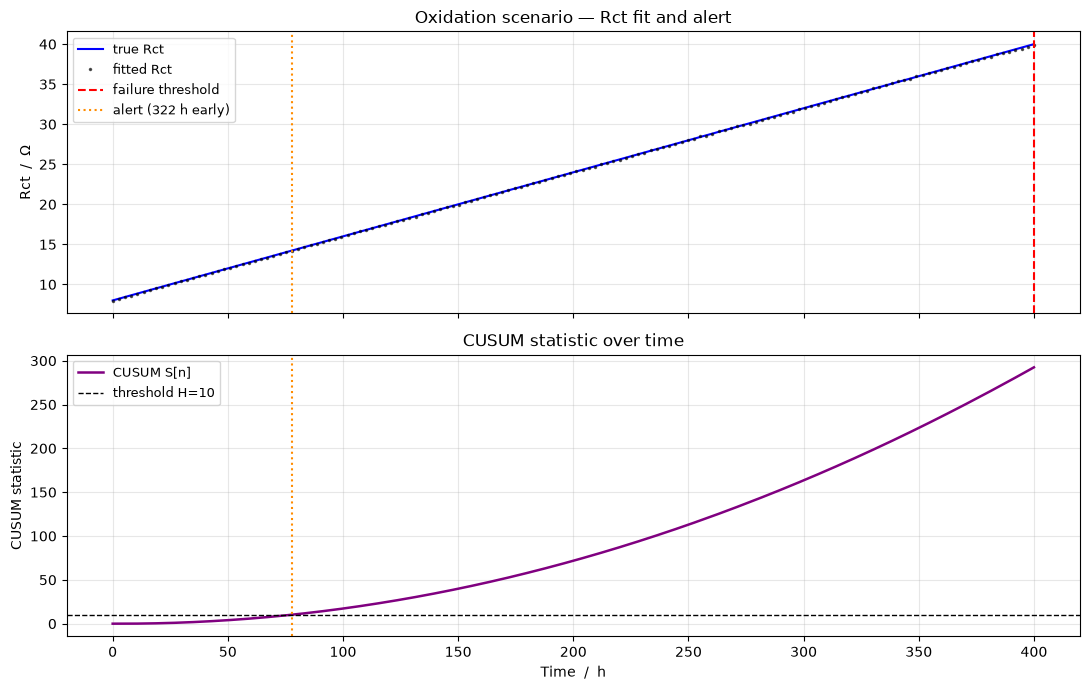

In [5]:
# ── Detailed view: one scenario end-to-end ───────────────────────────────────
ox_ex = oxidation_trajectory(n_steps=150, total_hours=400)
fitted_ex = fit_scenario(ox_ex, frequencies=freqs, snr_db=40.0, rng=np.random.default_rng(7))
rct_ex = extract_rct(fitted_ex)
result_ex = cusum_detector(
    rct_ex, ox_ex.hours,
    baseline_rct=baseline.Rct,
    threshold=10.0, drift=0.05,
    failure_hour=ox_ex.failure_hour,
)

print(f"Alert at {result_ex.alert_hour:.0f} h  |  failure at {ox_ex.failure_hour:.0f} h  |  lead = {result_ex.lead_hours:.0f} h")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Rct trajectory
true_rct = ox_ex.rct_series()
axes[0].plot(ox_ex.hours, true_rct, 'b-', lw=1.5, label='true Rct')
axes[0].plot(ox_ex.hours, rct_ex, 'k.', ms=3, alpha=0.6, label='fitted Rct')
axes[0].axvline(ox_ex.failure_hour, color='red', ls='--', label='failure threshold')
if result_ex.alert_hour:
    axes[0].axvline(result_ex.alert_hour, color='darkorange', ls=':', label=f'alert ({result_ex.lead_hours:.0f} h early)')
axes[0].set_ylabel('Rct  /  Ω')
axes[0].set_title('Oxidation scenario — Rct fit and alert')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# CUSUM statistic
axes[1].plot(ox_ex.hours, result_ex.statistic, 'purple', lw=1.8, label='CUSUM S[n]')
axes[1].axhline(10.0, color='black', ls='--', lw=1, label='threshold H=10')
if result_ex.alert_hour:
    axes[1].axvline(result_ex.alert_hour, color='darkorange', ls=':')
axes[1].set_xlabel('Time  /  h')
axes[1].set_ylabel('CUSUM statistic')
axes[1].set_title('CUSUM statistic over time')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/03-cusum-example.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Summary claim ─────────────────────────────────────────────────────────────
print("=" * 60)
print("FALSIFIABLE CLAIM (synthetic data only)")
print("=" * 60)
print(f"  Dataset      : {n_deg} degraded (oxidation+evaporation), {n_hlth} healthy")
print(f"  Noise model  : additive complex Gaussian at SNR=40 dB")
print(f"  Detector     : CUSUM on fitted Rct, threshold H=10, drift k=0.05")
print(f"  TPR          : {metrics.true_positive_rate:.1%}")
print(f"  FPR          : {metrics.false_positive_rate:.1%}")
print(f"  Median lead  : {metrics.median_lead_hours:.1f} h before Rct failure")
print(f"  Min lead     : {metrics.min_lead_hours:.1f} h")
print("")
print("WHAT THIS DOES NOT PROVE:")
print("  - Real high-temperature EIS data behaviour")
print("  - Generalisation to other bath chemistries or current densities")
print("  - Robustness to non-Gaussian noise (cable inductance, thermal EMF)")
print("  - Multi-physics coupling (thermal runaway, convection)")

FALSIFIABLE CLAIM (synthetic data only)
  Dataset      : 60 degraded (oxidation+evaporation), 30 healthy
  Noise model  : additive complex Gaussian at SNR=40 dB
  Detector     : CUSUM on fitted Rct, threshold H=10, drift k=0.05
  TPR          : 100.0%
  FPR          : 0.0%
  Median lead  : 211.5 h before Rct failure
  Min lead     : 96.4 h

WHAT THIS DOES NOT PROVE:
  - Real high-temperature EIS data behaviour
  - Generalisation to other bath chemistries or current densities
  - Robustness to non-Gaussian noise (cable inductance, thermal EMF)
  - Multi-physics coupling (thermal runaway, convection)
